# **Cancellation Analysis**

## Objectives

* Answer business requirement 1:

    *The client wants to understand cancellation patterns, trends and guest booking behaviour across their portfolio in order to identify risk factors and develop more effective cancellation defence strategies*

## Inputs

* outputs/datasets/collection/HotelBookings.csv

## Outputs

* Generate code that answers business requirement 1 and can be used in future processes




---

## Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))

current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect'

## Load Data

In [4]:
import pandas as pd
df = pd.read_csv("outputs/datasets/collection/HotelBookings.csv")
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
1,Resort Hotel,0,737,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
2,Resort Hotel,0,7,2023,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02


* Remove `reservation_status` and `reservation_status_date` due to data leak against target variable.

In [5]:
df = df.drop(columns=["reservation_status", "reservation_status_date"])
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2023,July,27,1,0,0,2,...,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2023,July,27,1,0,0,2,...,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2023,July,27,1,0,1,1,...,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0


## Dataset Overview

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

* The dataset comprises 119390 rows across 30 features.

In [6]:
from ydata_profiling import ProfileReport
profile_report = ProfileReport(df, minimal=True)
profile_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

* The dataset overview shows 3.6% missing cells and all dtypes are int64, float64 or object.
* Several variables display unusual outliers. children and babies having max values of 10 each, required_car_parking_spaces having a max value of 8 and the max value of 5400 for adr is an extreme outlier. adr also shows 1 negative value and 1959 zero values. All these values should be referred to the client for verification.
* Several of the variables are categorical-as-numeric. is_canceled and is_repeated_guest are binary in nature, arrival_date_year has 3 classes and both company and agent are numeric ID codes 
* children, babies, previous_cancellations, previous_bookings_not_canceled, days_in_waiting_list, booking_changes and required_car_parking_spaces all are heavily skewed with over 80% of the values zero
* lead_time and adr are skewed and may benefit from transformation if linear models are used
* arrival_date_week_number and arrival_date_day_of_month are reasonably evenly distributed as would be expected 
* country has 177 categories with gbr and prt accounting for 50% of bookings and the top 10 values accounting for nearly 85% of values. For plotting purposes, I will use the top 10 and group the remaining into other.
* Several of the categorical variables are dominated by one value. Potentially relevant examples are: deposit_type: "No Deposit", meal: "BB", market_segment: "Online TA", distribution_channel: "TA/TO", customer_type: "Transient"
* Several others have very sparse categories which may warrent grouping at a later stage such as market_segment where "direct", "corporate", "complimentary", "aviation" and "undefined" collectively account for less than 10% of the bookings.

---

## Target Variable Analysis

**Cancellation Distibution**

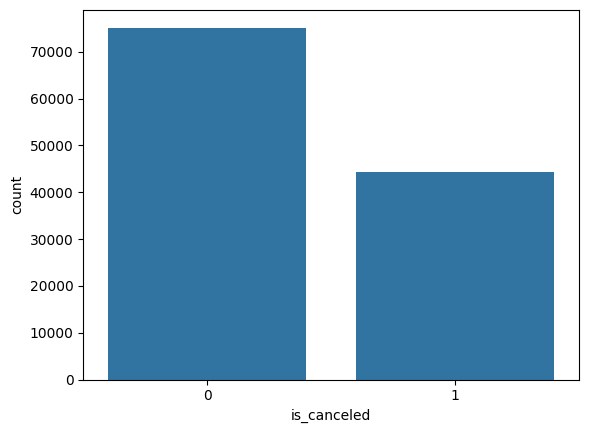

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.countplot(data=df,
              x="is_canceled")
plt.show()

* The plot shows a moderate class imbalance, the following steps evaluate that further:

In [8]:
target = df["is_canceled"]
cxl_df = pd.DataFrame({"Value": target.unique(),
                       "Frequency": target.value_counts().reset_index(drop=True),
                       "Percentage": target.value_counts(normalize=True)})

cxl_df.style.bar(subset=["Percentage"], color="darkgreen").format({"Percentage": "{:.0%}"})

,Value,Frequency,Percentage
0,0,75166,63%
1,1,44224,37%


* The overall cancellation rate is 37% indicating a moderate class imbalance that will require consideration during modelling.

**Cancellation by hotel type**

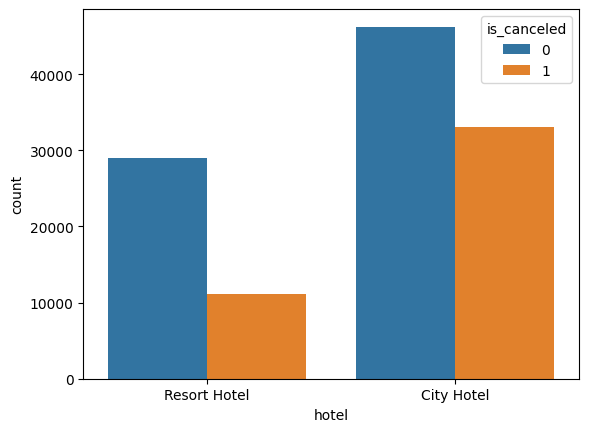

In [9]:
sns.countplot(data=df,
              x="hotel",
              hue="is_canceled")
plt.show()

* The city hotel shows both more bookings and more cancellations that the resort hotel. The city hotel appears to have a higher cancellation rate than the resort hotel.

In [10]:
df_by_hotel = pd.DataFrame({"cancellations": target.groupby(df["hotel"]).sum(),
                            "total_bookings": target.groupby(df["hotel"]).size()}).reset_index()
df_by_hotel["cancellation_rate"] = df_by_hotel["cancellations"] / df_by_hotel["total_bookings"]
df_by_hotel["percentage_of_total_cancellations"] = df_by_hotel["cancellations"] / df_by_hotel["cancellations"].sum()

df_by_hotel.drop(columns=["total_bookings"]).style.bar(
    subset=["cancellation_rate", "percentage_of_total_cancellations"], 
    color="darkgreen").format({"cancellation_rate": "{:.0%}","percentage_of_total_cancellations": "{:.0%}"})

,hotel,cancellations,cancellation_rate,percentage_of_total_cancellations
0,City Hotel,33102,42%,75%
1,Resort Hotel,11122,28%,25%


* This confirms that the city hotel has a higher percentage of cancellations compared to the resort hotel. This is, in part, offset by the increase in total bookings. While the city hotel accounts for 75% of all cancellations, their cancellation rate is 42% - only slightly higer than the overall cancellation rate of 37%, but significantly higher statistically than the resort hotel at 28%

**Periodicity Study**

* Check date dtypes

In [11]:
df[["arrival_date_year", "arrival_date_month"]].dtypes

arrival_date_year      int64
arrival_date_month    object
dtype: object

* Change month dtype to categorical to maintain calendar order

In [12]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=month_order, ordered=True)
df[["arrival_date_year", "arrival_date_month"]].dtypes

arrival_date_year        int64
arrival_date_month    category
dtype: object

* Prepare monthly and yearly cancellation rates for plotting

In [13]:
df_by_year = pd.DataFrame({"year": df["arrival_date_year"].unique(),
                           "cancellation_rate": target
                           .groupby(df["arrival_date_year"])
                           .mean()
                           .reset_index(drop=True)
                           })
df_by_year.style.format({"cancellation_rate": "{:.0%}"})

,year,cancellation_rate
0,2023,37%
1,2024,36%
2,2025,39%


In [14]:

df_by_month = pd.DataFrame({"cancellation_rate": target
                           .groupby([df["arrival_date_year"], df["arrival_date_month"]], observed=True)
                           .mean()
                           })
df_by_month.style.format({"cancellation_rate": "{:.0%}"})

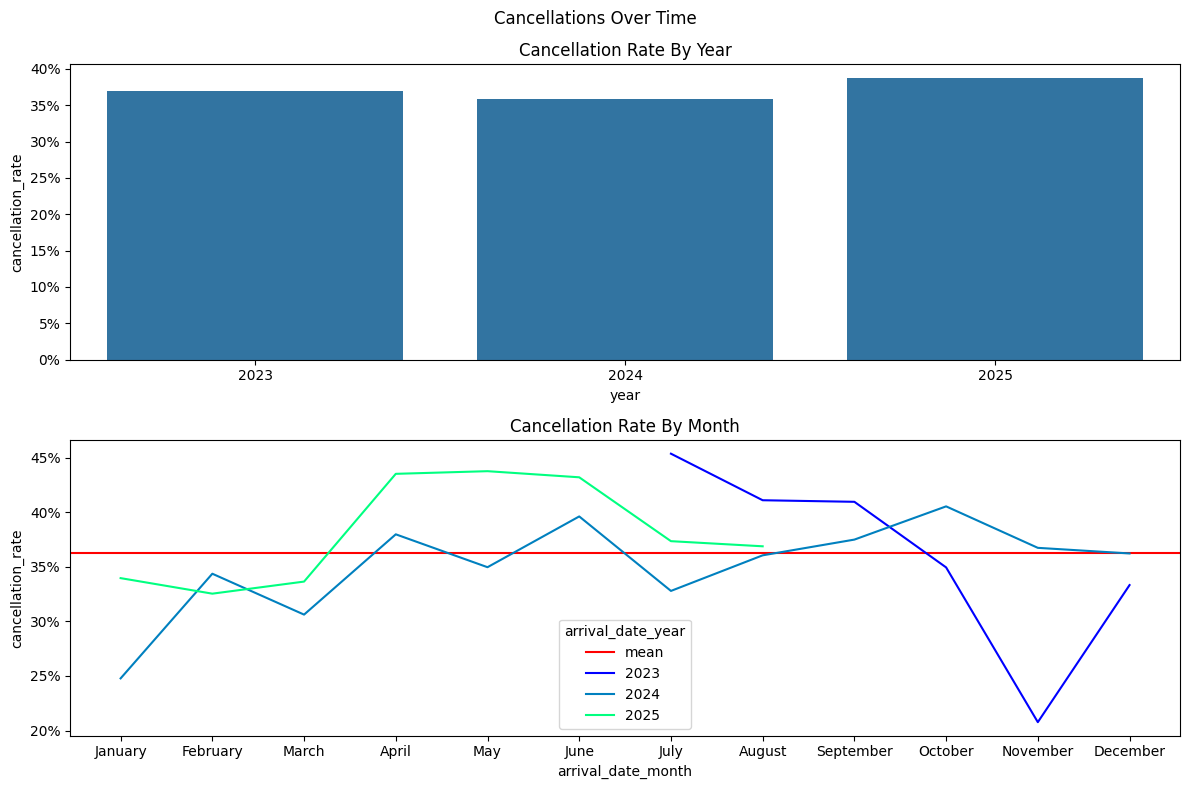

In [15]:
import matplotlib.ticker as mticker

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("Cancellations Over Time")
ax1.set_title("Cancellation Rate By Year")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.set_title("Cancellation Rate By Month")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.axhline(df_by_month["cancellation_rate"].mean(), color="red", label="mean")

sns.barplot(data=df_by_year,
            x="year",
            y="cancellation_rate",
            ax=ax1)

sns.lineplot(data=df_by_month,
             x="arrival_date_month",
             y="cancellation_rate",
             hue="arrival_date_year",
             palette="winter",
             ax=ax2)

plt.tight_layout()
plt.show()

* The cancellation rate per year is very balanced
* The cancellation rate per month shows some patterns worth further exploration, though the incomplete nature of 2023 and 2025 make it difficult to draw any definitive conclusions.

---

## Feature Analysis

* Visualise the features individually to undertand their distribution before introducing the target variable.

**Numeric Features**

In [16]:
def numeric_features(df):
    col_list = []
    for col in df.columns.to_list():
        if df[col].dtypes == "int64" or df[col].dtypes == "float64":
            col_list.append(col)
    return col_list       
        
col_list = numeric_features(df)
print(col_list)
len(col_list)

['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


20

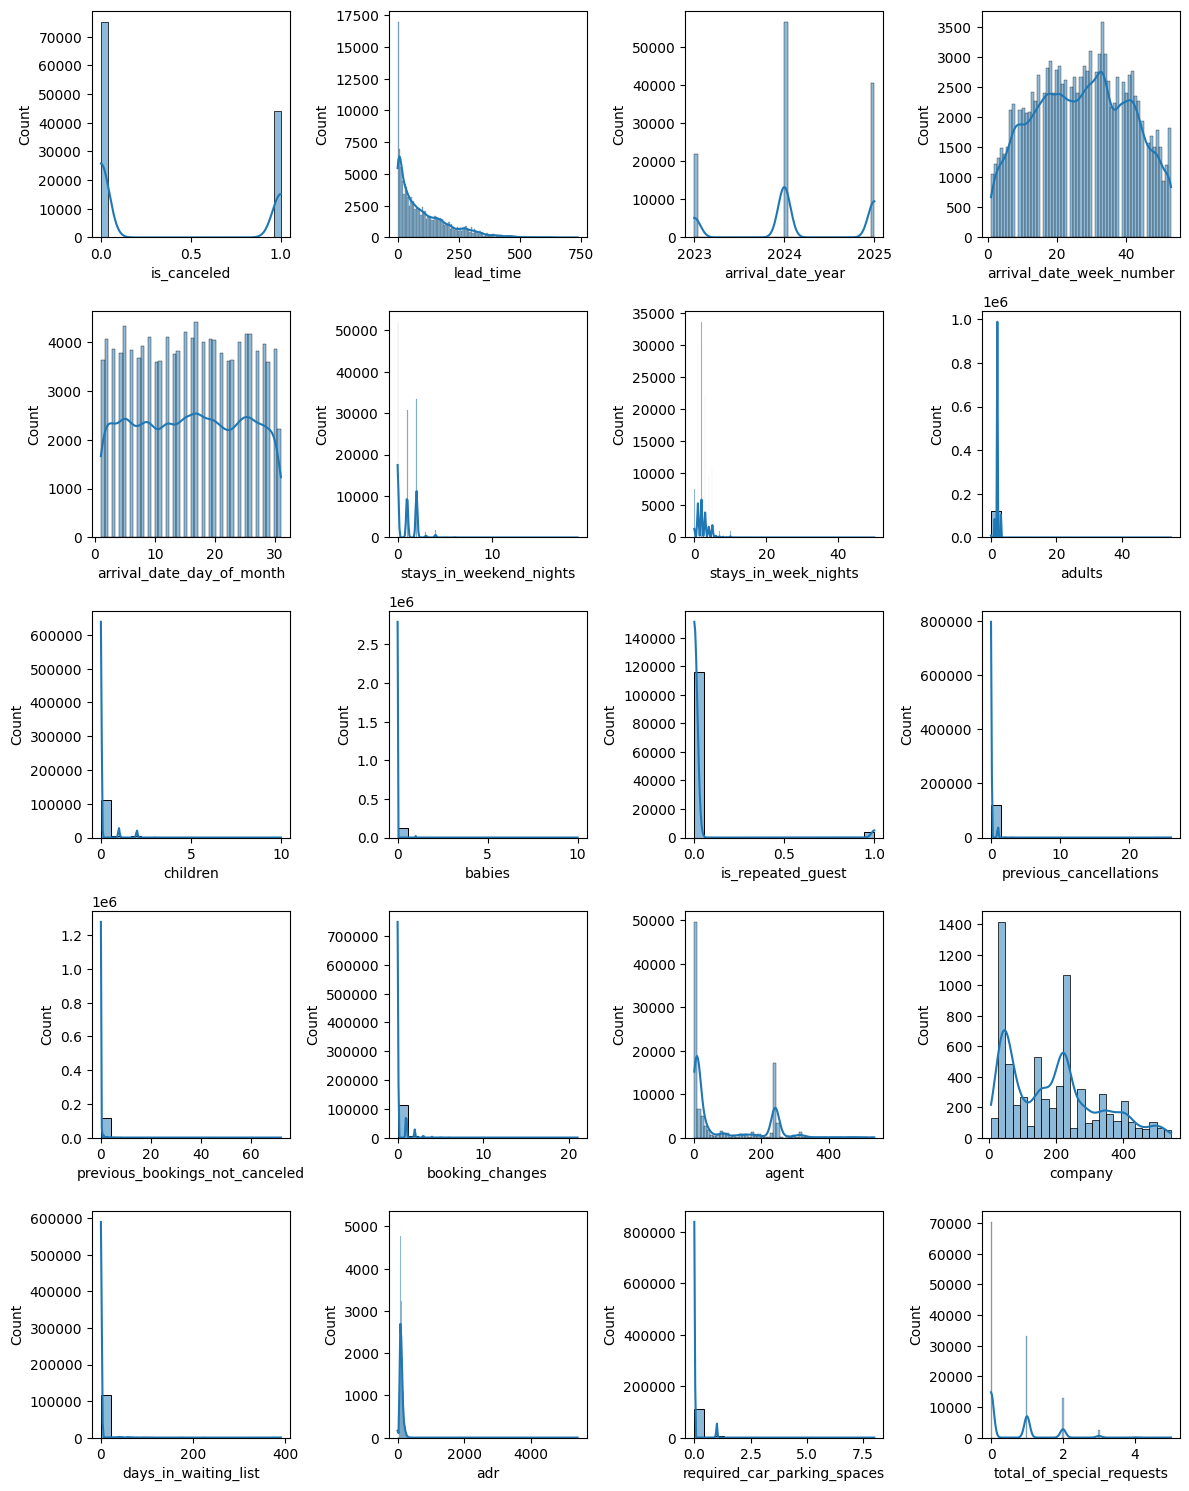

In [17]:
import math

def plot_numeric_features(cols):
    ncols = 4
    nrows = math.ceil(len(cols) / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(12, 15))
    axs = axs.flatten()

    for i, col in enumerate(cols):
        sns.histplot(data=df,
                     x=col,
                     kde=True,
                     ax=axs[i])

    plt.tight_layout()

plot_numeric_features(col_list)

* The visual plots reinforce the findings from the profile report.

**Categoric Features**

In [18]:
def categoric_features(df):
    col_list = []
    for col in df.columns.to_list():
        if df[col].dtypes == "object" or df[col].dtypes == "category":
            col_list.append(col)
    return col_list     

col_list = categoric_features(df)
col_list.remove("country") # Remove from list to plot separately
print(col_list)
len(col_list)  


['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


9

* Create dataframe of top ten countries with the remainder combined into "Other"

In [19]:
country = df["country"].value_counts(sort=True, ascending=False)
country_top_10 = country.iloc[:10]
other = pd.Series(country.iloc[10:].sum(), index=["Other"])
country = pd.concat([country_top_10, other])

country = pd.DataFrame(country, columns=["count"])
country = country.reset_index()
country = country.rename(columns={"index": "country"})
country

,country,count
0,PRT,48590
1,GBR,12129
2,FRA,10415
3,ESP,8568
4,DEU,7287
5,ITA,3766
6,IRL,3375
7,BEL,2342
8,BRA,2224
9,NLD,2104


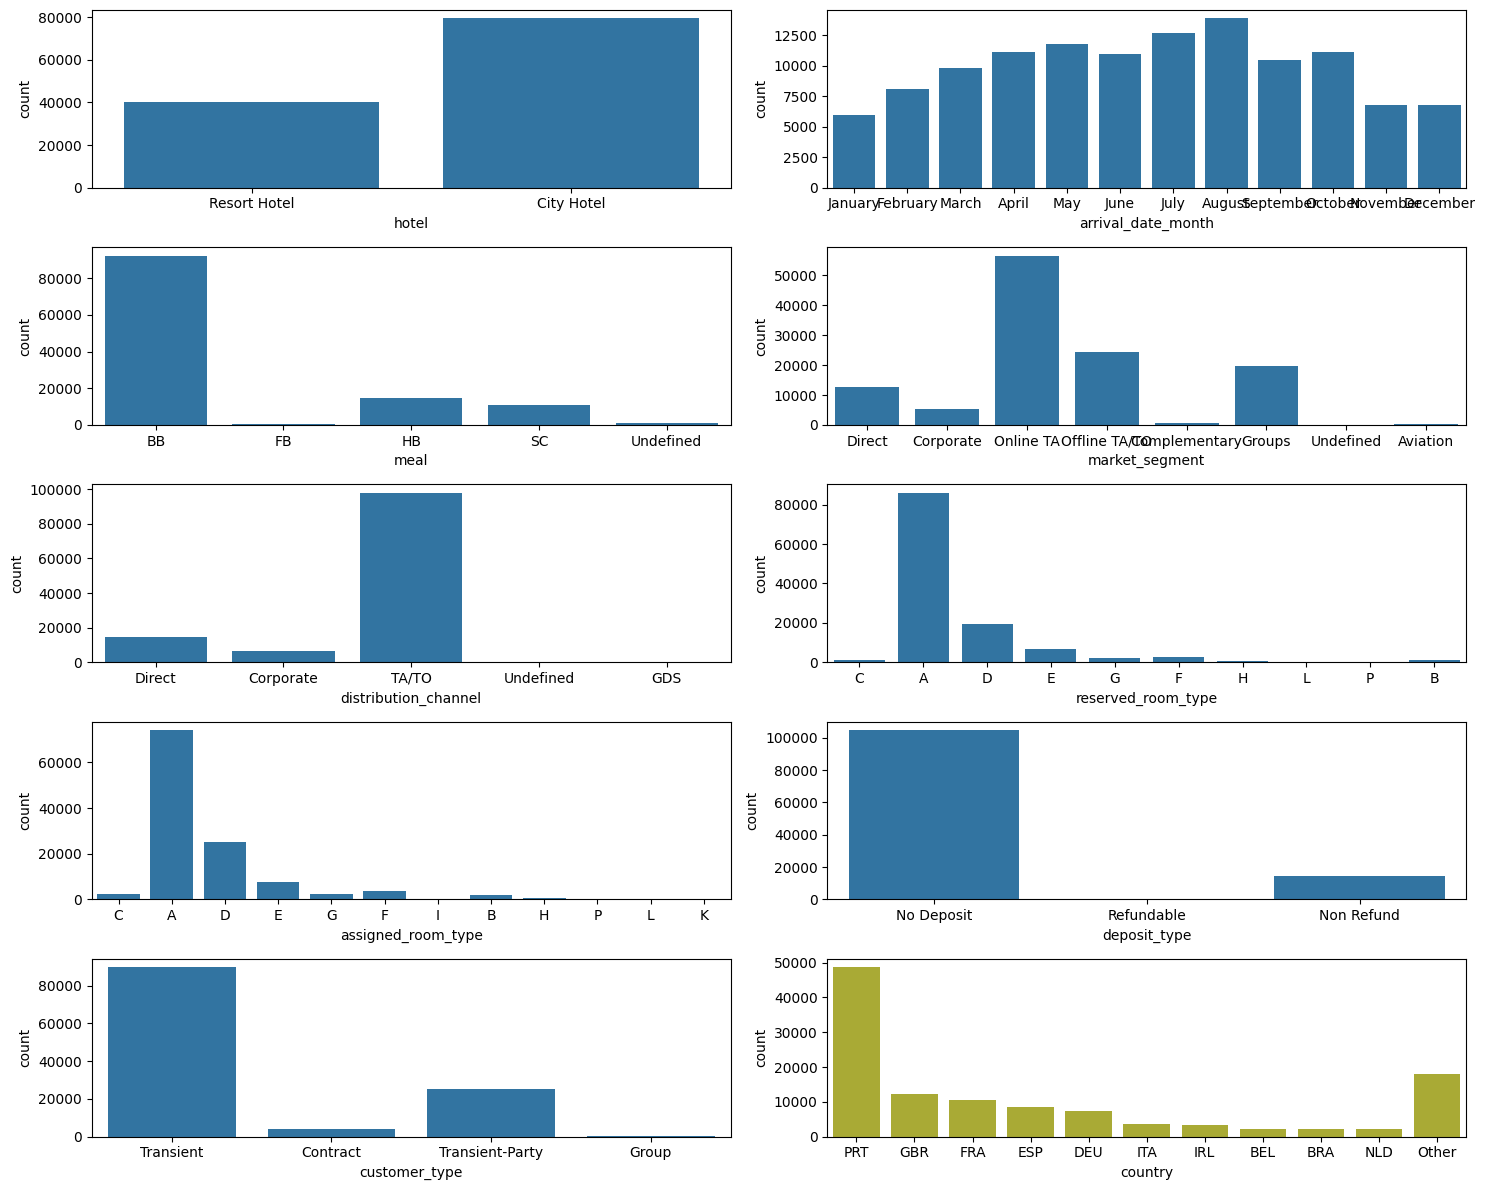

In [20]:
def plot_categoric_features(cols):
    ncols = 2
    nrows = math.ceil(len(cols) / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(15, 12))
    axs = axs.flatten()

    for i, col in enumerate(cols):
        sns.countplot(data=df,
                     x=col,
                     ax=axs[i])
        
        sns.barplot(data=country,
                    x="country",
                    y="count",
                    ax=axs[-1])

    plt.tight_layout()

plot_categoric_features(col_list)

* The city hotel accounts for approximately 2/3 of the total bookings
* arrival_date_month displays a reasonably even distribution following expected seasonal pattern
* Domestic bookings account for 40% of all arrivals

---

## Bivariate Analysis

* Plot each feature of interest against is_canceled.
    * H1 feature of interest: deposit_type
    * H2 feature of interest: lead_time
    * H3 features of interest: distribution_channel and market_segment - while market_segment specifically references OTAs, it is worth plotting distribution_channel also since TA/TO covers the same bookings while broadening the scope  

**deposit_type vs is_canceled**

In [21]:
h1_df = pd.crosstab(df["deposit_type"], target, normalize="index")
h1_df.columns = ["not_canceled", "canceled"]

h1_df.style.format({"not_canceled": "{:.0%}", "canceled": "{:.0%}"})

,not_canceled,canceled
deposit_type,,
No Deposit,72%,28%
Non Refund,1%,99%
Refundable,78%,22%


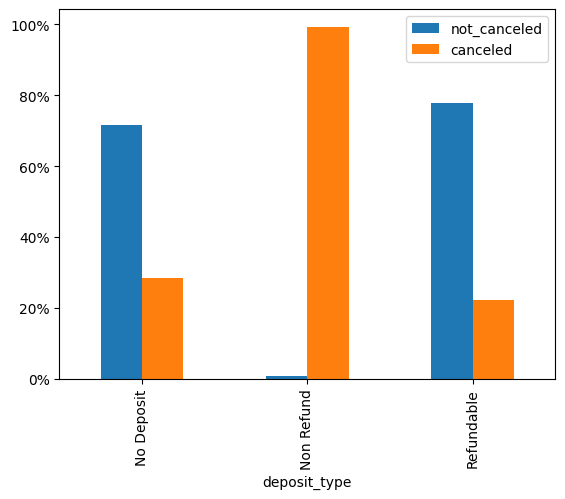

In [22]:
h1_df.plot(kind="bar").yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.show()

* A surprising result on the percentage of non-refundable bookings cancelled - the expectation here was that pre-paid, non-refundable bookings would be less likely to cancel.
* The data as presented does not support H1 insofar as bookings with a refundable deposit cancel only marginally less than bookings with no deposit. Bookings with non refundable deposits are almost guaranteed to cancel.

* Due to the unexpected nature of the non-refund category and the large number of unresolved duplicates, this will be run again without the duplicate bookings.

In [26]:
h1_unique_df = df.drop_duplicates(keep="first")
h1_unique_df = pd.crosstab(h1_unique_df["deposit_type"], target, normalize="index")
h1_unique_df.columns = ["not_canceled", "canceled"]

h1_unique_df.style.format({"not_canceled": "{:.0%}", "canceled": "{:.0%}"})

,not_canceled,canceled
deposit_type,,
No Deposit,74%,26%
Non Refund,5%,95%
Refundable,76%,24%


* While there has been a 4% shift, the overall picture remains much the same for non-refundable bookings with a cancellation rate still in excess of 90%. This suggests that potential duplicates merely inflate an existing pattern rather than create an anomaly.

**lead_time vs is_canceled**

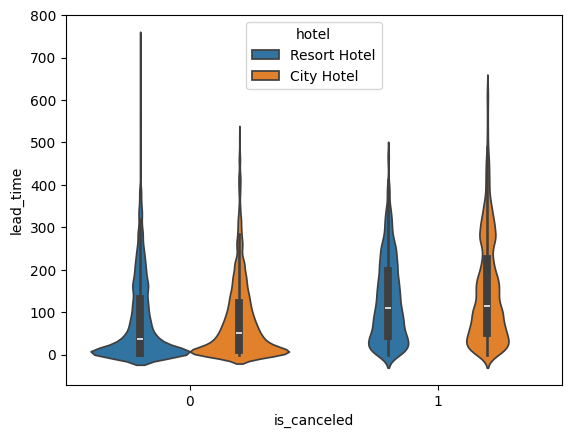

In [38]:
sns.violinplot(data=df, x="is_canceled", y="lead_time", hue="hotel")
plt.show()

* Cancelled bookings show a higher median lead time and a noticeably wider, flatter spread than non-cancelled bookings for both hotel types. This supports H2 - bookings made further in advance are more likely to cancel. Non-cancelled bookings are heavily concentrated near zero lead time, visible in the sharp bulge at the base of both violins.

* To further explore this, the data will be split into time buckets as follows:
    * Last Minute: 0-7 days
    * Short Range: 8-30 days
    * Mid Range: 31-90 days
    * Long Range: More than 90 days

In [39]:
import numpy as np

bins = [-np.inf, 7 ,30 ,90, np.inf]
lead_time = pd.cut(df["lead_time"], bins, labels=["Last Minute", "Short Range", "Mid Range", "Long Range"])
lead_time

0          Long Range
1          Long Range
2         Last Minute
3         Short Range
4         Short Range
             ...     
119385    Short Range
119386     Long Range
119387      Mid Range
119388     Long Range
119389     Long Range
Name: lead_time, Length: 119390, dtype: category
Categories (4, object): ['Last Minute' < 'Short Range' < 'Mid Range' < 'Long Range']

In [40]:
h2_df = df.copy()
h2_df["lead_time"] = lead_time
h2_df = pd.crosstab(h2_df["lead_time"], target, normalize="index")
h2_df.columns = ["not_canceled", "canceled"]

h2_df.style.format({"not_canceled": "{:.0%}", "canceled": "{:.0%}"})

,not_canceled,canceled
lead_time,,
Last Minute,90%,10%
Short Range,72%,28%
Mid Range,62%,38%
Long Range,49%,51%


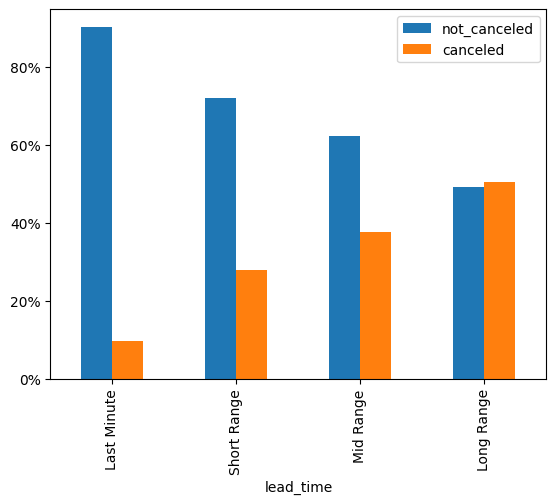

In [41]:
h2_df.plot(kind="bar").yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.show()

* This clearly demonstrates the relationship between booking lead time and the likelihood of cancellation. The cancellation rate rises steadily across each bucket. Last minute bookings (lead time 0-7 days) have only a 10% cancellation rate whereas the long ramge bookings (90+ days) cancel more than they arrive at 51% cancellations. The data supports H2.

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In case you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [22]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (2852421808.py, line 5)